In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset, Subset
from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")

print("BASE_DIR:", BASE_DIR)
print("Train exists:", os.path.isdir(TRAIN_DIR))
print("Some train subfolders:", os.listdir(TRAIN_DIR)[:10])

BASE_DIR: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
Train exists: True
Some train subfolders: ['7', '17', '19', '22', '2', '35', '23', '10', '5', '36']


In [3]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [4]:
full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)  
class_to_idx = full_dataset.class_to_idx            
id_to_internal = {int(k): v for k, v in class_to_idx.items()}

print("\nMapping ClassId -> internal idx:")
for cid in sorted(id_to_internal.keys())[:10]:
    print(cid, "->", id_to_internal[cid])


Mapping ClassId -> internal idx:
0 -> 0
1 -> 1
2 -> 12
3 -> 23
4 -> 34
5 -> 38
6 -> 39
7 -> 40
8 -> 41
9 -> 42


In [5]:

train_full = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_full   = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)

num_classes  = len(train_full.classes)
class_to_idx = train_full.class_to_idx
id_to_internal = {int(k): v for k, v in class_to_idx.items()}

print("Кількість класів:", num_classes)
print("Загальна кількість зображень:", len(train_full))

train_size = int(0.8 * len(train_full))

generator = torch.Generator().manual_seed(42)
indices   = torch.randperm(len(train_full), generator=generator).tolist()

train_dataset = Subset(train_full, indices[:train_size])
val_dataset   = Subset(val_full,   indices[train_size:])

print("Train size:", len(train_dataset))
print("Val size:  ", len(val_dataset))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size,
                          shuffle=False, num_workers=2)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Кількість класів: 43
Загальна кількість зображень: 39209
Train size: 31367
Val size:   7842
Device: cuda


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

weights = ViT_B_16_Weights.IMAGENET1K_V1
model   = vit_b_16(weights=weights)


for param in model.parameters():
    param.requires_grad = False


for i, block in enumerate(model.encoder.layers):
    if i >= 9:
        for param in block.parameters():
            param.requires_grad = True

model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

print("Навчуваних параметрів:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

model = model.to(device)

Device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 197MB/s]  


Навчуваних параметрів: 21296683


In [7]:
import torch
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4 
)

In [8]:
max_epochs = 40
patience   = 5   
min_delta  = 1e-4   

best_val_loss = float("inf")
best_state_dict = None
epochs_no_improve = 0

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

for epoch in range(max_epochs):

    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train   = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

    
        optimizer.zero_grad()

     
        outputs = model(imgs)
        loss = criterion(outputs, labels)

    
        loss.backward()

    
        optimizer.step()

        running_train_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct_train += (preds == labels).sum().item()
        total_train   += labels.size(0)

    avg_train_loss = running_train_loss / len(train_loader)
    train_acc      = correct_train / total_train

    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

   
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct_val += (preds == labels).sum().item()
            total_val   += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_acc      = correct_val / total_val

    val_losses.append(avg_val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{max_epochs} | "
        f"train_loss: {avg_train_loss:.4f}, train_acc: {train_acc:.4f} | "
        f"val_loss: {avg_val_loss:.4f}, val_acc: {val_acc:.4f}"
    )

   
    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_state_dict = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve} epoch(s).")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}.")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print("\nLoaded best model weights (minimal val_loss).")

Epoch 1/40 | train_loss: 0.5287, train_acc: 0.8513 | val_loss: 0.2611, val_acc: 0.9193
Epoch 2/40 | train_loss: 0.1325, train_acc: 0.9583 | val_loss: 0.1316, val_acc: 0.9584
Epoch 3/40 | train_loss: 0.0821, train_acc: 0.9741 | val_loss: 0.1335, val_acc: 0.9584
  No improvement for 1 epoch(s).
Epoch 4/40 | train_loss: 0.0638, train_acc: 0.9803 | val_loss: 0.1036, val_acc: 0.9652
Epoch 5/40 | train_loss: 0.0559, train_acc: 0.9819 | val_loss: 0.0898, val_acc: 0.9703
Epoch 6/40 | train_loss: 0.0452, train_acc: 0.9857 | val_loss: 0.0824, val_acc: 0.9744
Epoch 7/40 | train_loss: 0.0417, train_acc: 0.9863 | val_loss: 0.0666, val_acc: 0.9783
Epoch 8/40 | train_loss: 0.0376, train_acc: 0.9887 | val_loss: 0.0795, val_acc: 0.9745
  No improvement for 1 epoch(s).
Epoch 9/40 | train_loss: 0.0333, train_acc: 0.9891 | val_loss: 0.0469, val_acc: 0.9852
Epoch 10/40 | train_loss: 0.0328, train_acc: 0.9902 | val_loss: 0.0543, val_acc: 0.9829
  No improvement for 1 epoch(s).
Epoch 11/40 | train_loss: 0.03

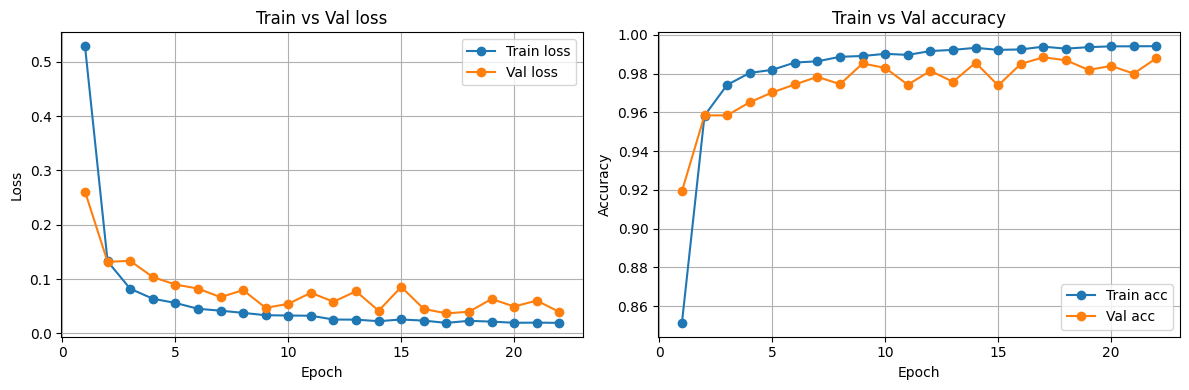

In [9]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, marker="o", label="Train loss")
plt.plot(epochs_range, val_losses,   marker="o", label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Val loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, marker="o", label="Train acc")
plt.plot(epochs_range, val_accs,   marker="o", label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Val accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [10]:
torch.save(model.state_dict(), "/kaggle/working/vit_gtsrb.pth")

In [12]:
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

BASE_DIR = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
TEST_CSV = os.path.join(BASE_DIR, "Test.csv")
TEST_DIR = os.path.join(BASE_DIR, "Test")

test_df = pd.read_csv(TEST_CSV)
print(test_df.head())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png


In [13]:
class GTSRBTestDataset(Dataset):
    def __init__(self, df, base_dir, class_id_to_idx, transform=None, use_roi=True):
        self.df = df.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.class_id_to_idx = class_id_to_idx  # мапа ClassId -> internal index
        self.use_roi = use_roi

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.base_dir, row["Path"])  # e.g. "Test/00000.png"

        img = Image.open(img_path).convert("RGB")

        if self.use_roi:
            x1 = int(row["Roi.X1"])
            y1 = int(row["Roi.Y1"])
            x2 = int(row["Roi.X2"])
            y2 = int(row["Roi.Y2"])
            img = img.crop((x1, y1, x2, y2))

        class_id = int(row["ClassId"])
        label = self.class_id_to_idx[class_id]   

        if self.transform:
            img = self.transform(img)

        return img, label

In [15]:
class_to_idx = full_dataset.class_to_idx
id_to_internal = {int(k): v for k, v in class_to_idx.items()}

test_dataset = GTSRBTestDataset(
    test_df,
    BASE_DIR,
    class_id_to_idx=id_to_internal,
    transform=eval_transform,
    use_roi=True
)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
print("class_to_idx:", full_dataset.class_to_idx)

print("\nMapping ClassId -> internal idx:")
for cid in sorted(id_to_internal.keys())[:10]:
    print(cid, "->", id_to_internal[cid])

class_to_idx: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}

Mapping ClassId -> internal idx:
0 -> 0
1 -> 1
2 -> 12
3 -> 23
4 -> 34
5 -> 38
6 -> 39
7 -> 40
8 -> 41
9 -> 42


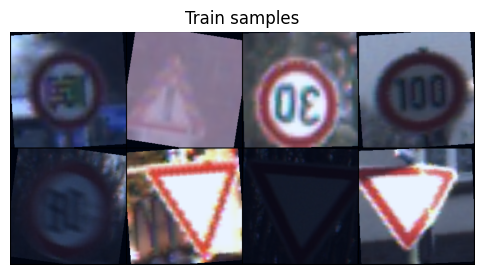

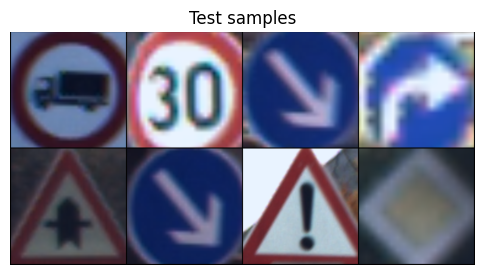

In [17]:
import torchvision

imgs, labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(imgs[:8], nrow=4, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(grid.permute(1, 2, 0))
plt.title("Train samples")
plt.axis("off")
plt.show()


imgs_t, labels_t = next(iter(test_loader))
grid_t = torchvision.utils.make_grid(imgs_t[:8], nrow=4, normalize=True)
plt.figure(figsize=(6,6))
plt.imshow(grid_t.permute(1, 2, 0))
plt.title("Test samples")
plt.axis("off")
plt.show()

In [18]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt


In [19]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


accuracy = accuracy_score(all_labels, all_preds)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels,
    all_preds,
    average="macro",  
    zero_division=0
)

print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro):    {recall_macro:.4f}")
print(f"F1-score (macro):  {f1_macro:.4f}")


try:
    class_names = full_dataset.classes
except NameError:
 
    class_names = [str(i) for i in range(len(set(all_labels)))]

print("\nClassification report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
))

Accuracy:          0.8918
Precision (macro): 0.8636
Recall (macro):    0.8175
F1-score (macro):  0.8275

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89        60
           1       0.97      0.93      0.95       720
          10       0.91      0.99      0.95       660
          11       1.00      0.97      0.98       420
          12       1.00      0.99      0.99       690
          13       0.99      0.99      0.99       720
          14       0.98      0.91      0.94       270
          15       1.00      0.99      1.00       210
          16       1.00      0.89      0.94       150
          17       1.00      0.96      0.98       360
          18       0.76      0.92      0.83       390
          19       0.73      0.82      0.77        60
           2       0.83      0.99      0.90       750
          20       0.77      0.90      0.83        90
          21       0.98      0.57      0.72        90
       

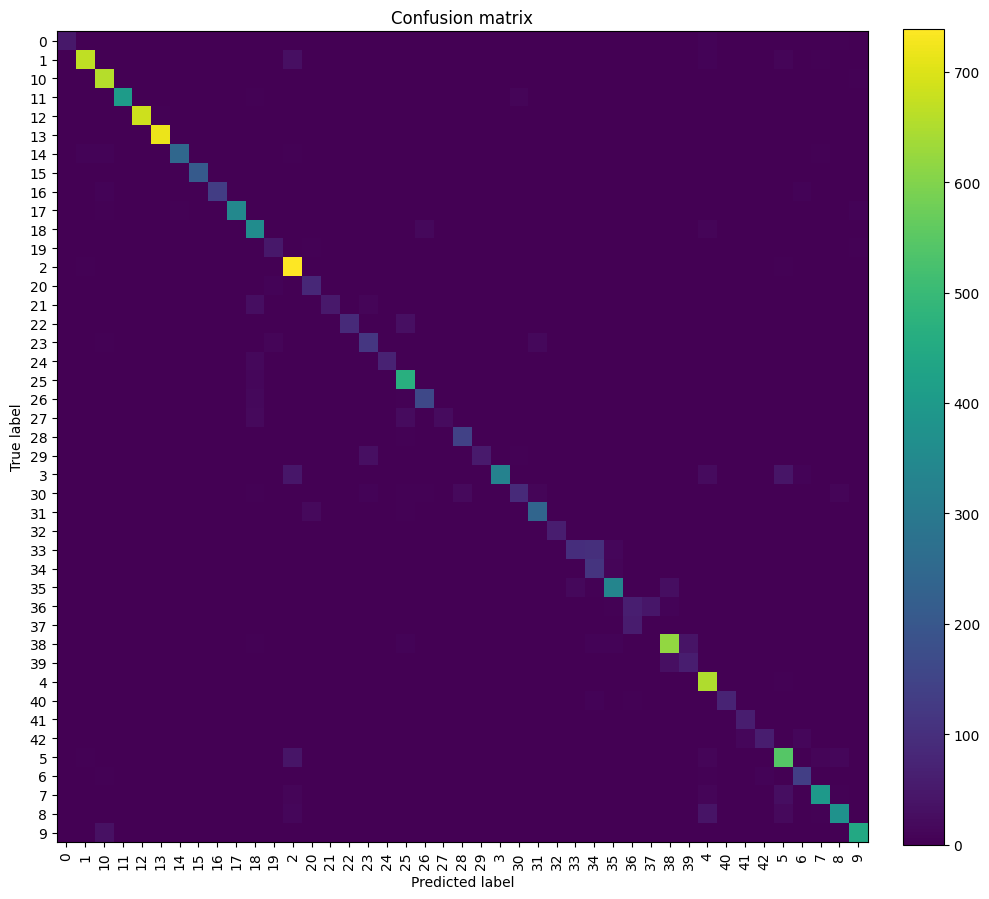

In [20]:
cm = confusion_matrix(all_labels, all_preds)
num_classes = len(class_names)

plt.figure(figsize=(10, 10))
im = plt.imshow(cm, interpolation="nearest")
plt.title("Confusion matrix")
plt.colorbar(im, fraction=0.046, pad=0.04)

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

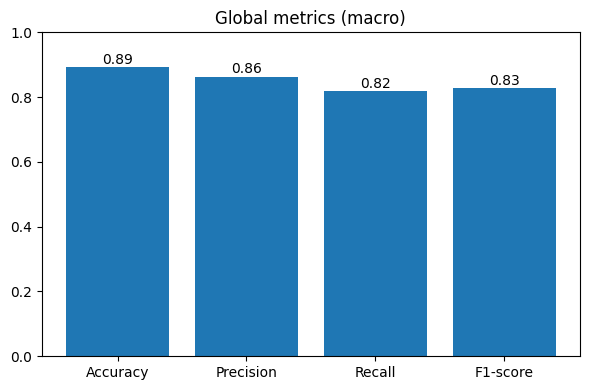

In [21]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metrics_values = [accuracy, precision_macro, recall_macro, f1_macro]

plt.figure(figsize=(6, 4))
plt.bar(metrics_names, metrics_values)
plt.ylim(0, 1.0)
plt.title("Global metrics (macro)")
for i, v in enumerate(metrics_values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()


In [22]:
print(f"Пристрій моделі: {next(model.parameters()).device}")
print(f"Стан моделі (навчання): {model.training}")

weights_sum = sum(p.sum() for p in model.parameters())
print(f"Контрольна сума ваг: {weights_sum.item()}")

Пристрій моделі: cuda:0
Стан моделі (навчання): False
Контрольна сума ваг: 13346.498046875


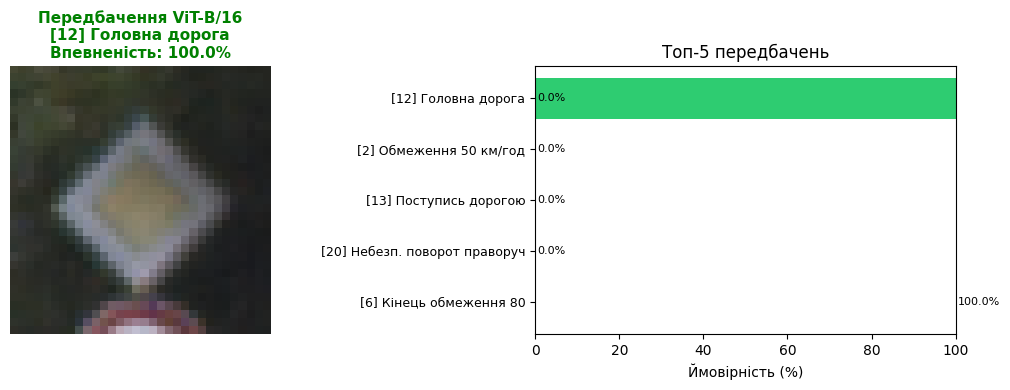


────────────────────────────────────────────────
  Модель      : ViT-B/16
  Клас ID     : 12
  Назва       : Головна дорога
  Впевненість : 100.00%
────────────────────────────────────────────────


(12, 'Головна дорога', 0.9999604225158691)

In [24]:
import torch.nn.functional as F

CLASS_NAMES = {
    0:  "Обмеження 20 км/год",      1:  "Обмеження 30 км/год",
    2:  "Обмеження 50 км/год",      3:  "Обмеження 60 км/год",
    4:  "Обмеження 70 км/год",      5:  "Обмеження 80 км/год",
    6:  "Кінець обмеження 80",      7:  "Обмеження 100 км/год",
    8:  "Обмеження 120 км/год",     9:  "Заборона обгону",
    10: "Заборона обгону (вант.)",  11: "Пріоритет на перехресті",
    12: "Головна дорога",           13: "Поступись дорогою",
    14: "Стоп",                     15: "Рух заборонено",
    16: "Вант. транспорт заборон.", 17: "В'їзд заборонено",
    18: "Увага",                    19: "Небезп. поворот ліворуч",
    20: "Небезп. поворот праворуч", 21: "Подвійний поворот",
    22: "Нерівна дорога",           23: "Слизька дорога",
    24: "Звуження праворуч",        25: "Дорожні роботи",
    26: "Світлофор",                27: "Пішохідний перехід",
    28: "Діти",                     29: "Велосипедисти",
    30: "Ожеледиця/сніг",           31: "Дикі тварини",
    32: "Кінець усіх обмежень",     33: "Поворот праворуч",
    34: "Поворот ліворуч",          35: "Прямо обов'язково",
    36: "Прямо або праворуч",       37: "Прямо або ліворуч",
    38: "Тримайтесь праворуч",      39: "Тримайтесь ліворуч",
    40: "Кільцевий рух",            41: "Кінець заборони обгону",
    42: "Кінець заборони обгону (вант.)",
}

internal_to_id = {v: k for k, v in id_to_internal.items()}

def predict_single(image_path, top_k=5):

    if str(image_path).startswith("http"):
        import requests
        from io import BytesIO
        img = Image.open(BytesIO(requests.get(image_path).content)).convert("RGB")
    else:
        img = Image.open(image_path).convert("RGB")


    tensor = eval_transform(img).unsqueeze(0).to(device)


    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)[0]   # [43]


    top_probs, top_idxs = torch.topk(probs, top_k)
    top_probs = top_probs.cpu().numpy()
    top_ids   = [internal_to_id[i.item()] for i in top_idxs]
    top_names = [CLASS_NAMES.get(cid, f"Клас {cid}") for cid in top_ids]

    best_id   = top_ids[0]
    best_name = top_names[0]
    best_conf = float(top_probs[0])


    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].imshow(img)
    axes[0].axis("off")
    color = "green" if best_conf > 0.7 else "orange"
    axes[0].set_title(
        f"Передбачення ViT-B/16\n[{best_id}] {best_name}\nВпевненість: {best_conf:.1%}",
        fontsize=11, fontweight="bold", color=color
    )

    bars = axes[1].barh(
        range(top_k - 1, -1, -1),
        top_probs * 100,
        color=["#2ecc71" if i == 0 else "#3498db" for i in range(top_k)]
    )
    labels_short = [f"[{cid}] {nm[:28]}" for cid, nm in zip(top_ids, top_names)]
    axes[1].set_yticks(range(top_k - 1, -1, -1))
    axes[1].set_yticklabels(labels_short, fontsize=9)
    axes[1].set_xlabel("Ймовірність (%)")
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f"Топ-{top_k} передбачень")
    for bar, val in zip(bars, top_probs[::-1]):
        axes[1].text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                     f"{val:.1%}", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\n{'─'*48}")
    print(f"  Модель      : ViT-B/16")
    print(f"  Клас ID     : {best_id}")
    print(f"  Назва       : {best_name}")
    print(f"  Впевненість : {best_conf:.2%}")
    print(f"{'─'*48}")
    return best_id, best_name, best_conf

IMAGE_PATH = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00007.png"

predict_single(IMAGE_PATH, top_k=5)


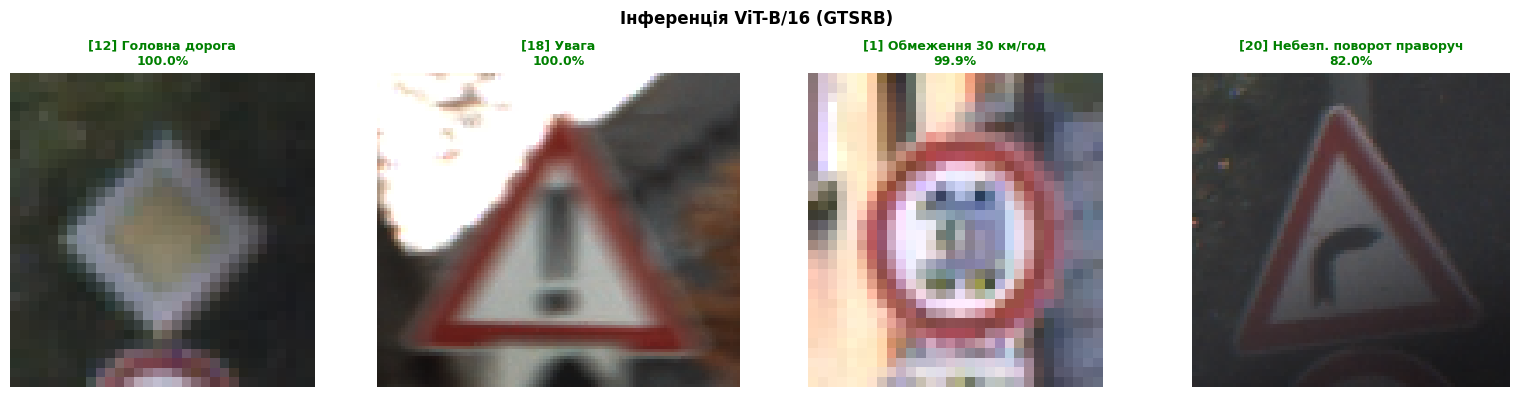

In [25]:
def predict_grid(image_paths):
    n = len(image_paths)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    model.eval()
    for ax, path in zip(axes, image_paths):
        img = Image.open(path).convert("RGB")
        tensor = eval_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            probs = F.softmax(model(tensor), dim=1)[0]

        top_prob, top_idx = probs.max(0)
        class_id = internal_to_id[top_idx.item()]
        name     = CLASS_NAMES.get(class_id, f"Клас {class_id}")
        conf     = top_prob.item()

        ax.imshow(img)
        ax.axis("off")
        color = "green" if conf > 0.7 else "orange"
        ax.set_title(f"[{class_id}] {name}\n{conf:.1%}",
                     fontsize=9, color=color, fontweight="bold")

    plt.suptitle("Інференція ViT-B/16 (GTSRB)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Кілька зображень з тестового набору:
test_samples = [
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00007.png",
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00042.png",
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00100.png",
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test/00250.png",
]
predict_grid(test_samples)


In [26]:
import torch

torch.save(model.cpu().state_dict(), "/kaggle/working/last_model.pth")